# 5.1 RQ1 Results — VARK Inference

This section consolidates the analysis of learners' self-reported VARK learning styles versus their actual in-game hint behaviors and completion rates.

In [1]:
### SETUP CELL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import mcnemar
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
us = pd.read_csv('users.csv')
hi = pd.read_csv('hints.csv')
ge = pd.read_csv('gameEvents.csv')

# 2. Prepare VARK Population
vark_cols = ['vark_visual', 'vark_aural', 'vark_reading', 'vark_kinesthetic']
vark = us[us[vark_cols].sum(axis=1) > 0].copy()
vark['total_vark'] = vark[vark_cols].sum(axis=1)
vark['finished']   = vark['exercisesSolved'] == 12
for col in vark_cols:
    vark[f'pct_{col}'] = vark[col] / vark['total_vark']

def classify_vark(row):
    scores = row[vark_cols].values.astype(float)
    total  = scores.sum()
    expected = [total / 4] * 4
    chi2, p = stats.chisquare(scores, f_exp=expected)
    return p < 0.05
vark['is_dominant'] = vark.apply(classify_vark, axis=1)

# 3. Game Events & Hint Times
ge['timestamp'] = pd.to_datetime(ge['timestamp'], utc=True)
ge = ge.sort_values(by=['userId', 'timestamp'])
ge['current_exerciseId'] = ge.groupby('userId')['exerciseId'].ffill()

hint_types = ['visual', 'read', 'kinesthetic', 'aural']
hints_only = ge[ge['modalType'].isin(hint_types)].copy()
hints_only['duration'] = pd.to_numeric(hints_only['duration'], errors='coerce').fillna(0)
hints_only['duration_sec'] = hints_only['duration'] / 1000
hints_only['modalType'] = hints_only['modalType'].replace({'read': 'reading'})

# 4. Correlation Data (merged, pairs)
time_pivot = hints_only.groupby(['userId', 'modalType'])['duration_sec'].sum().unstack(fill_value=0)
for col in ['aural','kinesthetic','reading','visual']:
    if col not in time_pivot.columns: time_pivot[col] = 0
time_pivot['total_time_sec'] = time_pivot[['aural','kinesthetic','reading','visual']].sum(axis=1)
time_pivot_filtered = time_pivot[time_pivot['total_time_sec'] >= 10].copy()
for col in ['aural','kinesthetic','reading','visual']:
    time_pivot_filtered[f'pct_{col}_time'] = time_pivot_filtered[col] / time_pivot_filtered['total_time_sec']

merged = vark.merge(time_pivot_filtered, on='userId', how='inner')
pairs = [
    ('pct_vark_visual',       'pct_visual_time',       'Visual'),
    ('pct_vark_aural',        'pct_aural_time',        'Aural'),
    ('pct_vark_reading',      'pct_reading_time',      'Reading'),
    ('pct_vark_kinesthetic',  'pct_kinesthetic_time',  'Kinesthetic'),
]

# 5. In-Game Dominance for McNemar's (c_table, percent_dominant)
hint_cols = ['aural', 'kinesthetic', 'reading', 'visual']
def classify_time_dominance(row):
    obs = row[hint_cols].values.astype(float)
    total = obs.sum()
    if total == 0: return False
    expected = [total / 4] * 4
    chi2, p = stats.chisquare(obs, f_exp=expected)
    return p < 0.05

time_pivot_filtered['is_dominant'] = time_pivot_filtered.apply(classify_time_dominance, axis=1)
total_valid_hint_users = len(time_pivot_filtered)
dominant_hint_users = time_pivot_filtered['is_dominant'].sum()
percent_dominant = (dominant_hint_users / total_valid_hint_users) * 100

paired_df = pd.merge(
    time_pivot_filtered.reset_index()[['userId', 'is_dominant']].rename(columns={'is_dominant': 'hint_dominant'}),
    vark[['userId', 'is_dominant']].rename(columns={'is_dominant': 'vark_dominant'}),
    on='userId', how='inner'
)
c_table = pd.crosstab(paired_df['hint_dominant'], paired_df['vark_dominant'])

# 6. Dropout / Completion (hint_summary, contingency_table)
hint_users_ids = set(hi['userId'])
vark['used_hints'] = vark['userId'].isin(hint_users_ids)
hint_summary = vark.groupby('used_hints')['finished'].agg(['sum','count'])
hint_summary['did_not_finish'] = hint_summary['count'] - hint_summary['sum']
hint_summary['finish_rate'] = hint_summary['sum'] / hint_summary['count'] * 100
hint_summary.index = ['No hints', 'Used hints']
contingency_table = pd.crosstab(vark['used_hints'], vark['finished'])

# 7. Hint Patterns by Actual Questions (q_pivot)
actual_q_hints = hints_only[hints_only['current_exerciseId'].isin(['q1', 'q2', 'q3'])].copy()
time_per_question = actual_q_hints.groupby(['challengeId', 'current_exerciseId', 'modalType']).agg(
    total_min=('duration_sec', lambda x: x.sum() / 60)
).reset_index()
time_per_question['challenge_q'] = time_per_question['challengeId'].str.replace('challenge-', 'Ch') + " - " + time_per_question['current_exerciseId'].str.upper()
q_pivot = time_per_question.pivot(index='challenge_q', columns='modalType', values='total_min').fillna(0)
hint_order = [h for h in ['aural', 'reading', 'visual', 'kinesthetic'] if h in q_pivot.columns]
q_pivot = q_pivot[hint_order]

# Globals
type_colors = {'aural':'#E07B39', 'visual':'#4C72B0', 'reading':'#5A9E6F', 'kinesthetic':'#7B66D2'}
print("Setup complete! You can now run the cells below independently.")

Setup complete! You can now run the cells below independently.


### 5.1.1 Participant Population
Out of 1212 total users, 576 completed the VARK questionnaire and passed quality question.


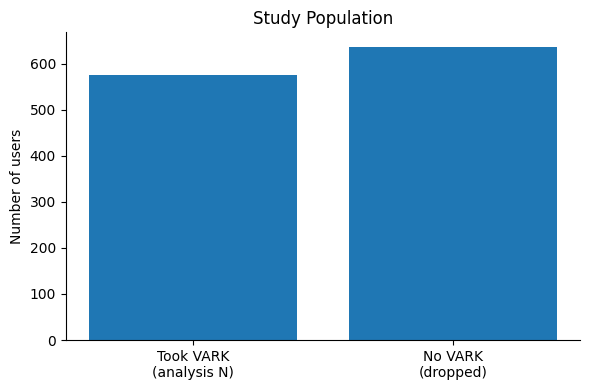

In [2]:
import matplotlib.pyplot as plt

# Plot: Who is in our study
plt.figure(figsize=(6, 4))

plt.bar(
    ['Took VARK\n(analysis N)', 'No VARK\n(dropped)'],
    [len(vark), len(us) - len(vark)]
)

plt.ylabel('Number of users')
plt.title('Study Population')

# Remove top and right spines
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 5.1.2 VARK–Hint Correlation
Learners do not disproportionately use hints matching their declared style.

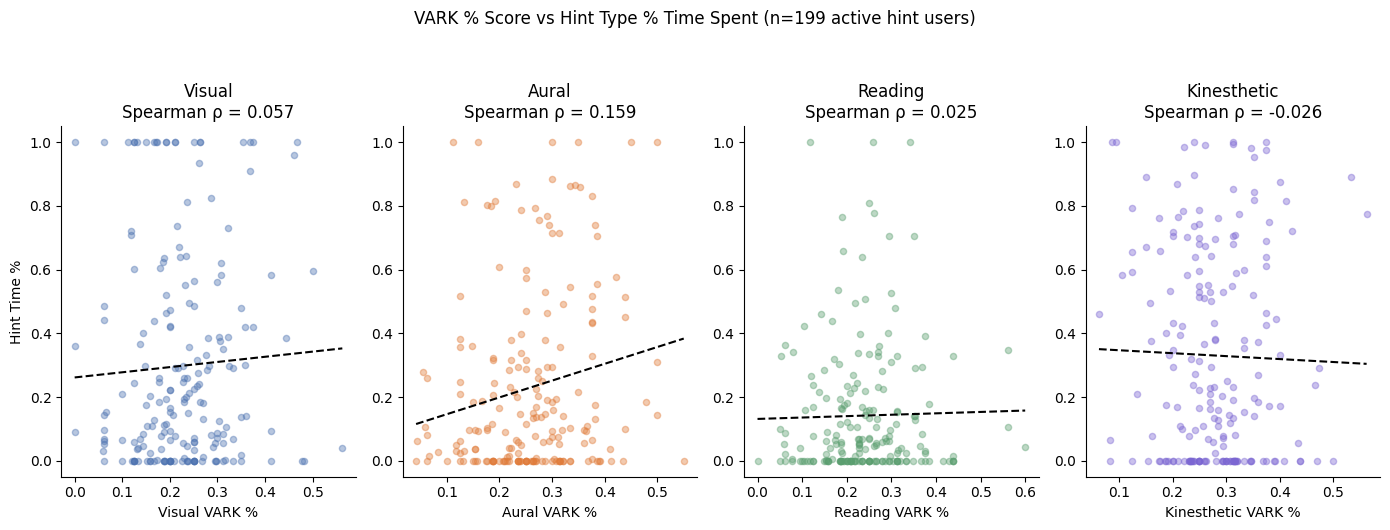

In [16]:
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
colors_style = {'Visual':'#4C72B0','Aural':'#E07B39','Reading':'#5A9E6F','Kinesthetic':'#7B66D2'}

for ax, (vark_col, hint_col, label) in zip(axes, pairs):
    x = merged[vark_col]
    y = merged[hint_col]

    # Calculate Spearman correlation
    s_r = x.corr(y, method='spearman')

    ax.scatter(x, y, alpha=0.4, s=20, color=colors_style[label])

    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, p(xline), color='black', linewidth=1.5, linestyle='--')

    ax.set_xlabel(f'{label} VARK %')
    if label == 'Visual': ax.set_ylabel('Hint Time %')

    # Display Spearman metric in the title
    ax.set_title(f'{label}\nSpearman ρ = {s_r:.3f}')
    ax.spines[['top','right']].set_visible(False)

fig.suptitle(f'VARK % Score vs Hint Type % Time Spent (n={len(merged)} active hint users)', fontsize=12, y=1.05)
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd
from scipy.stats import spearmanr

corr_results = []
for vark_col, hint_col, label in pairs:
    # Drop any NaNs just in case
    valid_data = merged[[vark_col, hint_col]].dropna()

    # Spearman (Rank / Monotonic)
    s_r, s_p_value = spearmanr(valid_data[vark_col], valid_data[hint_col])

    corr_results.append({
        'Modality': label,
        "Spearman's rho": round(s_r, 4),
        "Spearman p-value": round(s_p_value, 4)
    })

corr_df = pd.DataFrame(corr_results)
print("--- VARK Survey vs. In-Game Hint Correlation ---")
display(corr_df)


--- VARK Survey vs. In-Game Hint Correlation ---


,Modality,Spearman's rho,Spearman p-value
0,Visual,0.0575,0.4199
1,Aural,0.1593,0.0246
2,Reading,0.0252,0.7239
3,Kinesthetic,-0.0258,0.7176


### 5.1.3 Hint Modalities Difference: VARK vs. In-game Hints

- Chiquare within VARK and ingame
- mcnemar to evaluate the difference .

The particpant have dominated style in game , not in VARK


In [5]:
from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd

# --- 1. VARK Dominance (Chi-Square Results) ---
vark_dom_count = vark['is_dominant'].sum()
vark_total = len(vark)
print("--- VARK Survey Dominance ---")
print(f"Total VARK takers: {vark_total}")
print(f"Statistically dominant (p < 0.05): {vark_dom_count} ({(vark_dom_count/vark_total)*100:.1f}%)")
print(f"Multimodal: {vark_total - vark_dom_count} ({(1 - vark_dom_count/vark_total)*100:.1f}%)\n")

# --- 2. In-Game Hint Dominance (Chi-Square Results - VARK Takers Only) ---
# Filter to only users who took VARK and used hints >= 10s
vark_hint_users = time_pivot_filtered[time_pivot_filtered.index.isin(vark['userId'])]
hint_dom_count = vark_hint_users['is_dominant'].sum()
hint_total = len(vark_hint_users)
print("--- In-Game Hint Dominance (VARK Takers Only) ---")
print(f"Total valid hint users (VARK takers & >=10s): {hint_total}")
print(f"Statistically dominant (p < 0.05): {hint_dom_count} ({(hint_dom_count/hint_total)*100:.1f}%)")
print(f"Multimodal: {hint_total - hint_dom_count} ({(1 - hint_dom_count/hint_total)*100:.1f}%)\n")

# --- 3. McNemar Test (Comparing the Two) ---
print("--- McNemar's Test ---")
print(f"Sample size: N={len(paired_df)}")
print("Reason for N=199: This is the exact intersection of users who BOTH completed the VARK survey AND spent at least 10 seconds using hints in-game.\n")

print("Contingency Table (Rows: In-Game Hint Dominant | Cols: VARK Survey Dominant)")
display(c_table)

result = mcnemar(c_table, exact=True)
print(f"\nMcNemar's test p-value: {result.pvalue:.2e}")
if result.pvalue < 0.05:
    print("Conclusion: The shift from multimodal (in VARK) to dominant (in actual gameplay) is HIGHLY STATISTICALLY SIGNIFICANT.")


--- VARK Survey Dominance ---
Total VARK takers: 576
Statistically dominant (p < 0.05): 41 (7.1%)
Multimodal: 535 (92.9%)

--- In-Game Hint Dominance (VARK Takers Only) ---
Total valid hint users (VARK takers & >=10s): 199
Statistically dominant (p < 0.05): 190 (95.5%)
Multimodal: 9 (4.5%)

--- McNemar's Test ---
Sample size: N=199
Reason for N=199: This is the exact intersection of users who BOTH completed the VARK survey AND spent at least 10 seconds using hints in-game.

Contingency Table (Rows: In-Game Hint Dominant | Cols: VARK Survey Dominant)


vark_dominant,False,True
hint_dominant,,
False,8,1
True,180,10



McNemar's test p-value: 1.19e-52
Conclusion: The shift from multimodal (in VARK) to dominant (in actual gameplay) is HIGHLY STATISTICALLY SIGNIFICANT.


### 5.1.4 Hint Usage and Game Completion
Here, we analyze the game completion rate. "Hint users" are strictly defined as participants who spent at least 10 seconds using hints, consistent with the previous sections. Those who did not use hints or used them for less than 10 seconds are grouped as non-hint users.

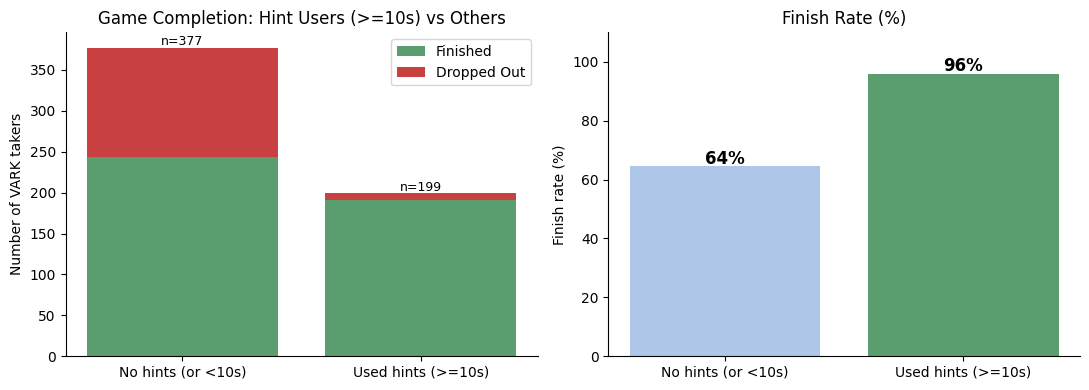

Chi-square statistic : 67.99
p-value              : 1.64e-16


In [6]:
from scipy.stats import chi2_contingency
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Recalculate based on >= 10s threshold ---
valid_hint_users_ids = set(time_pivot_filtered.index)
vark['used_hints_10s'] = vark['userId'].isin(valid_hint_users_ids)

hint_summary = vark.groupby('used_hints_10s')['finished'].agg(['sum','count'])
hint_summary['did_not_finish'] = hint_summary['count'] - hint_summary['sum']
hint_summary['finish_rate'] = hint_summary['sum'] / hint_summary['count'] * 100
hint_summary.index = ['No hints (or <10s)', 'Used hints (>=10s)']

contingency_table = pd.crosstab(vark['used_hints_10s'], vark['finished'])

# --- 2. Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: Finished vs Dropout
axes[0].bar(hint_summary.index, hint_summary['sum'], label='Finished', color='#5A9E6F')
axes[0].bar(hint_summary.index, hint_summary['did_not_finish'], bottom=hint_summary['sum'], label='Dropped Out', color='#C94040')
axes[0].set_ylabel('Number of VARK takers')
axes[0].set_title('Game Completion: Hint Users (>=10s) vs Others')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)
for i, (idx, row) in enumerate(hint_summary.iterrows()):
    axes[0].text(i, row['count']+3, f"n={row['count']:.0f}", ha='center', fontsize=9)

# Right: Finish rate
axes[1].bar(hint_summary.index, hint_summary['finish_rate'], color=['#aec7e8', '#5A9E6F'])
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Finish rate (%)')
axes[1].set_title('Finish Rate (%)')
axes[1].spines[['top','right']].set_visible(False)
for i, (idx, row) in enumerate(hint_summary.iterrows()):
    axes[1].text(i, row['finish_rate']+1, f"{row['finish_rate']:.0f}%", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# --- 3. Statistics ---
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic : {chi2:.2f}")
print(f"p-value              : {p:.2e}")


### 5.1.5 Hint usage Patterns
The time spent on hints varies drastically by challenge and question. The plot below maps the overall hint usage across the 12 actual exercises (q1, q2, q3 per challenge) with the kruskal test to validate if it is significant

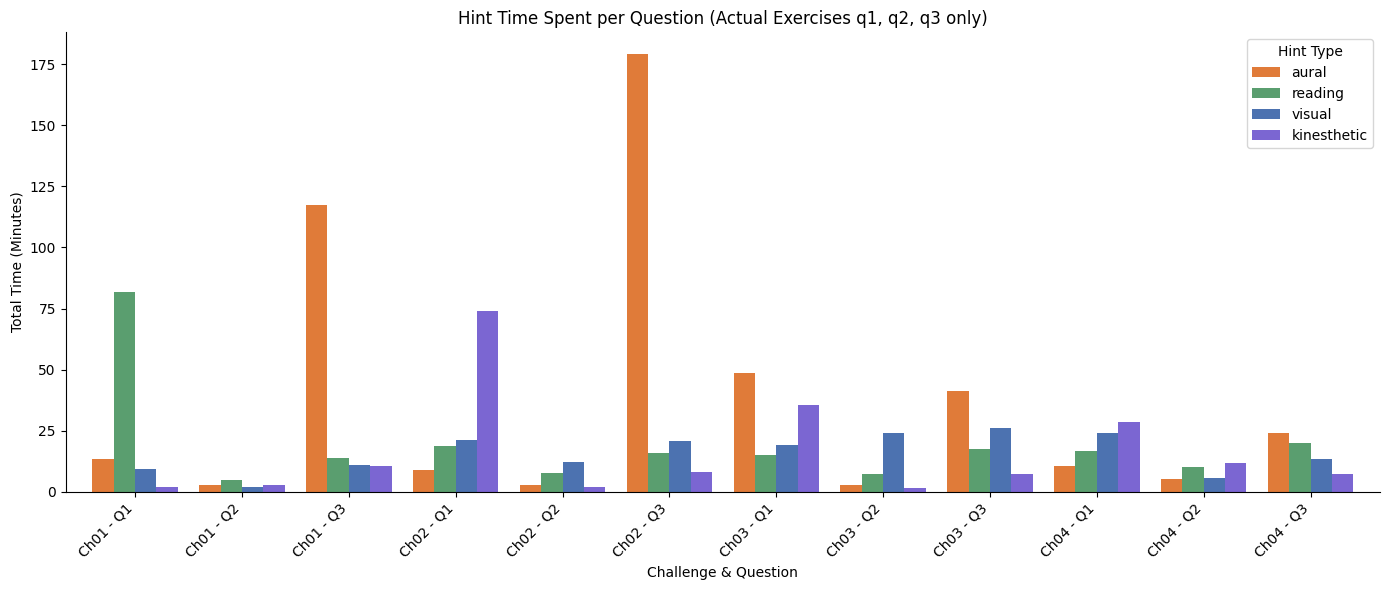

--- Statistical Significance of Hint Time Differences ---
Kruskal-Wallis H-statistic: 41.11
p-value: 6.20e-09
Conclusion: The difference in time spent per hint type across these exercises is statistically significant.


In [7]:
from scipy.stats import kruskal

# Plotting Hint Usage Patterns across the 12 actual questions
fig, ax = plt.subplots(figsize=(14, 6))

q_pivot.plot(kind='bar', ax=ax, width=0.8,
             color=[type_colors.get(c, '#CCCCCC') for c in q_pivot.columns])

ax.set_ylabel('Total Time (Minutes)')
ax.set_xlabel('Challenge & Question')
ax.set_title('Hint Time Spent per Question (Actual Exercises q1, q2, q3 only)')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Hint Type")
plt.tight_layout()
plt.show()

# Statistical test for differences in hint time
groups_overall = [actual_q_hints[actual_q_hints['modalType'] == m]['duration_sec'].dropna() for m in actual_q_hints['modalType'].unique()]
h_stat, p_val = kruskal(*groups_overall)

print("--- Statistical Significance of Hint Time Differences ---")
print(f"Kruskal-Wallis H-statistic: {h_stat:.2f}")
print(f"p-value: {p_val:.2e}")
if p_val < 0.05:
    print("Conclusion: The difference in time spent per hint type across these exercises is statistically significant.")
else:
    print("Conclusion: No significant difference in time spent per hint type.")

##5. 1. 6 Hint  Grouped Dominant
For users who demonstrated a statistically significant dominant hint preference (via the Chi-square test), this table summarizes the specific primary modality they favored.

In [8]:
import pandas as pd
import numpy as np

hint_cols = ['aural', 'kinesthetic', 'reading', 'visual']

def get_dominant_modality(row):
    if not row['is_dominant']:
        return 'Multimodal (Mixed)'
    # If chi-square indicates dominance, the dominant modality is the one with the maximum time
    return row[hint_cols].astype(float).idxmax()

# Filter to only users who took the VARK survey
vark_hint_users = time_pivot_filtered[time_pivot_filtered.index.isin(vark['userId'])].copy()

# Apply the classification
vark_hint_users['dominant_modality'] = vark_hint_users.apply(get_dominant_modality, axis=1)

# --- 1. Show the "Before Grouping" Raw Data Sample ---
print("--- 1. Sample of Individual User Profiles (Before Grouping) ---")
print("Showing the exact percentage of time spent on each hint type to illustrate the classification.")
pct_cols = ['pct_aural_time', 'pct_kinesthetic_time', 'pct_reading_time', 'pct_visual_time']

detailed_df = vark_hint_users[pct_cols + ['is_dominant', 'dominant_modality']].copy()
for col in pct_cols:
    detailed_df[col] = (detailed_df[col] * 100).round(1).astype(str) + '%'

# Display all 9 Multimodal users and a sample of 5 Dominant users
multimodal_sample = detailed_df[detailed_df['is_dominant'] == False]
dominant_sample = detailed_df[detailed_df['is_dominant'] == True].head(5)
display(pd.concat([multimodal_sample, dominant_sample]))


# --- 2. Show the Summarized Grouping ---
# Group and count the distribution of dominant types
dominant_distribution = vark_hint_users['dominant_modality'].value_counts().reset_index()
dominant_distribution.columns = ['In-Game Dominant Modality', 'Number of Users']

print("\n--- 2. Summary Distribution (After Grouping) ---")
display(dominant_distribution)

# --- 3. Export to CSV ---
csv_filename = 'vark_hint_users_dominance.csv'
vark_hint_users.to_csv(csv_filename)
print(f"\n--- 3. Export ---")
print(f"Exported the full raw data (including actual times and percentages) to {csv_filename}")


--- 1. Sample of Individual User Profiles (Before Grouping) ---
Showing the exact percentage of time spent on each hint type to illustrate the classification.


modalType,pct_aural_time,pct_kinesthetic_time,pct_reading_time,pct_visual_time,is_dominant,dominant_modality
userId,,,,,,
6lyR5GP55PaaMOEDVdro7PqULUm1,18.4%,33.3%,30.9%,17.4%,False,Multimodal (Mixed)
V1GIccJUruegbhv4QhivaNSWY5l2,31.8%,16.4%,16.7%,35.2%,False,Multimodal (Mixed)
VqkGgMjbEkeXNq92TU0te8JQaRB2,36.2%,15.5%,19.2%,29.1%,False,Multimodal (Mixed)
Ydgxx4mH05RVTV0PqsdNOss3UYw2,29.4%,36.8%,33.8%,0.0%,False,Multimodal (Mixed)
Z5SsoQMif2gZlanBymUeIFS0mQG3,24.5%,22.9%,22.9%,29.7%,False,Multimodal (Mixed)
gegRec6H2hcbDUoPHsnsoGkgB3D2,31.7%,13.3%,17.6%,37.5%,False,Multimodal (Mixed)
iqgMc6MVDqRm8ZfdJ9g2Ct4BaPp2,24.8%,40.0%,10.7%,24.5%,False,Multimodal (Mixed)
mBdwHVGpTiXJ0DTDjqZRpssFhJq2,19.1%,33.1%,16.1%,31.7%,False,Multimodal (Mixed)
p7h8y4RjubRBzP62V1A9Iw5Qn5q2,43.4%,23.2%,33.4%,0.0%,False,Multimodal (Mixed)



--- 2. Summary Distribution (After Grouping) ---


,In-Game Dominant Modality,Number of Users
0,kinesthetic,76
1,visual,57
2,aural,40
3,reading,17
4,Multimodal (Mixed),9



--- 3. Export ---
Exported the full raw data (including actual times and percentages) to vark_hint_users_dominance.csv


## LLM Usage

--- Mean Total Time Per User (seconds) ---
Visual      : 38.07
Aural/LLM   : 99.82
Reading     : 49.39
Kinesthetic : 146.11

--- Friedman Test for Overall Hint Time Differences ---
Friedman chi-square statistic : 40.0999
p-value                     : 1.0148e-08

Conclusion: There is a STATISTICALLY SIGNIFICANT difference in the total time spent across the different hint modalities.
The highest mean usage overall is: Kinesthetic


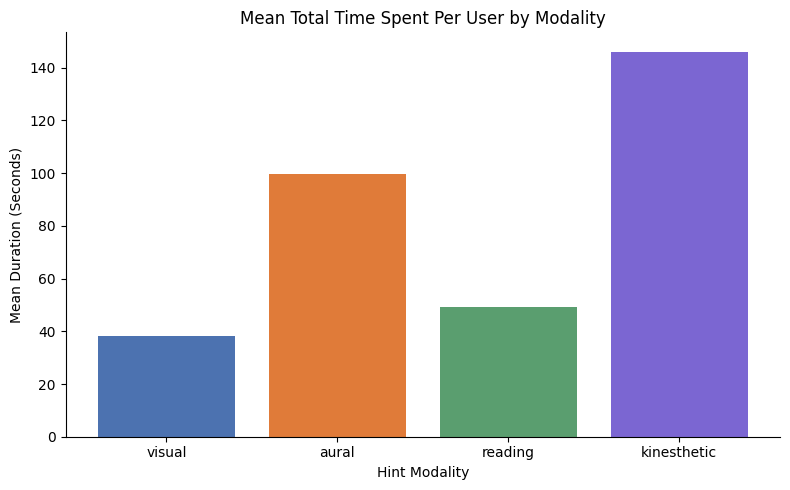

In [10]:
from scipy.stats import friedmanchisquare
import matplotlib.pyplot as plt

# 1. Create a matrix of total time per user per modality
user_time_matrix = hints_only.groupby(['userId', 'modalType'])['duration_sec'].sum().unstack(fill_value=0)

# Ensure all 4 modalities exist as columns, even if 0
for m in ['visual', 'aural', 'reading', 'kinesthetic']:
    if m not in user_time_matrix.columns:
        user_time_matrix[m] = 0

# Calculate and print the mean time per user
mean_per_user = user_time_matrix.mean()
print("--- Mean Total Time Per User (seconds) ---")
print(f"Visual      : {mean_per_user['visual']:.2f}")
print(f"Aural/LLM   : {mean_per_user['aural']:.2f}")
print(f"Reading     : {mean_per_user['reading']:.2f}")
print(f"Kinesthetic : {mean_per_user['kinesthetic']:.2f}\n")

# 2. Run Friedman test
stat, p_val = friedmanchisquare(
    user_time_matrix['visual'],
    user_time_matrix['aural'],
    user_time_matrix['reading'],
    user_time_matrix['kinesthetic']
)

print("--- Friedman Test for Overall Hint Time Differences ---")
print(f"Friedman chi-square statistic : {stat:.4f}")
print(f"p-value                     : {p_val:.4e}")

if p_val < 0.05:
    print("\nConclusion: There is a STATISTICALLY SIGNIFICANT difference in the total time spent across the different hint modalities.")
    most_used = mean_per_user.idxmax()
    print(f"The highest mean usage overall is: {most_used.capitalize()}")
else:
    print("\nConclusion: There is NO statistically significant difference in time spent across modalities.")

# 3. Plot the means
plt.figure(figsize=(8, 5))
mean_ordered = mean_per_user.reindex(['visual', 'aural', 'reading', 'kinesthetic'])
plt.bar(
    mean_ordered.index,
    mean_ordered.values,
    color=[type_colors.get(x, '#333') for x in mean_ordered.index]
)
plt.title('Mean Total Time Spent Per User by Modality')
plt.ylabel('Mean Duration (Seconds)')
plt.xlabel('Hint Modality')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


In [12]:
from scipy.stats import friedmanchisquare
import pandas as pd

# 1. Calculate Mean Total Time Per User by Modality for EACH Question
# First, create a complete matrix of time spent by each user on each question per modality
q_user_matrix = hints_only.groupby(['challengeId', 'current_exerciseId', 'userId', 'modalType'])['duration_sec'].sum().unstack(fill_value=0).reset_index()

# Ensure all 4 modalities exist as columns, even if 0
for m in ['visual', 'aural', 'reading', 'kinesthetic']:
    if m not in q_user_matrix.columns:
        q_user_matrix[m] = 0

# Group by challenge and question to get the mean per user
mean_q_user = q_user_matrix.groupby(['challengeId', 'current_exerciseId'])[['visual', 'aural', 'reading', 'kinesthetic']].mean()

print("--- Mean Total Time Per User by Modality and Question (Seconds) ---")
display(mean_q_user.round(2))

# 2. Run Friedman Test specifically for each Q3
print("\n--- Friedman Test for Each Q3 ---")
q3_data = q_user_matrix[q_user_matrix['current_exerciseId'] == 'q3']
unique_challenges = q3_data['challengeId'].unique()

for challenge in sorted(unique_challenges):
    # Isolate data for this specific challenge's Q3
    chal_q3 = q3_data[q3_data['challengeId'] == challenge]

    # Run the test
    stat, p_val = friedmanchisquare(
        chal_q3['visual'],
        chal_q3['aural'],
        chal_q3['reading'],
        chal_q3['kinesthetic']
    )

    print(f"\n{challenge.upper()} - Q3:")
    print(f"Friedman chi-square statistic : {stat:.4f}")
    print(f"p-value                     : {p_val:.4e}")

    if p_val < 0.05:
        means = chal_q3[['visual', 'aural', 'reading', 'kinesthetic']].mean()
        most_used = means.idxmax()
        print(f"Conclusion: STATISTICALLY SIGNIFICANT difference.")
        print(f"Highest mean usage: {most_used.capitalize()} ({means[most_used]:.2f} seconds)")
    else:
        print("Conclusion: NO statistically significant difference.")


--- Mean Total Time Per User by Modality and Question (Seconds) ---


modalType                                visual   aural  reading  kinesthetic
challengeId  current_exerciseId                                              
challenge-01 challenge-01-kinesthetic-1    0.00    0.00     0.00        56.76
             challenge-01-kinesthetic-2    0.00    0.00     0.00        95.24
             challenge-01-kinesthetic-3    0.41   37.54    22.23       120.02
             challenge-02-kinesthetic-3    0.00    0.00     0.00         0.00
             q1                           10.09   14.30    87.50         2.15
             q2                            3.97    5.75     9.18         5.41
             q3                            8.47   90.30    10.59         8.17
challenge-02 challenge-02-kinesthetic-1    6.61    2.71    10.02        53.94
             challenge-02-kinesthetic-2    0.00    0.00     0.00       134.14
             challenge-02-kinesthetic-3    2.97   20.32     3.11       155.36
             q1                           19.88    8.45    17.65        69.53
             q2                           19.46    4.51    12.17         3.05
             q3                           13.69  118.11    10.43         5.30
challenge-03 challenge-03-kinesthetic-1    0.00   39.32     5.21       489.59
             challenge-03-kinesthetic-2    0.00    0.00     0.00       252.52
             challenge-03-kinesthetic-3    1.10    4.34     2.12       348.61
             q1                           16.46   41.74    12.88        30.42
             q2                           31.56    3.61     9.26         1.98
             q3                           17.65   27.97    11.86         4.84
challenge-04 challenge-04-kinesthetic-1    0.68    0.00     2.06        73.78
             challenge-04-kinesthetic-2    0.00    0.00     0.00       105.67
             challenge-04-kinesthetic-3    1.34   14.00     4.87       150.26
             q1                           28.82   12.63    19.91        34.42
             q2                           10.24    9.34    18.15        20.59
             q3                           10.67   19.19    16.08         5.87


--- Friedman Test for Each Q3 ---

CHALLENGE-01 - Q3:
Friedman chi-square statistic : 6.8337
p-value                     : 7.7393e-02
Conclusion: NO statistically significant difference.

CHALLENGE-02 - Q3:
Friedman chi-square statistic : 18.0158
p-value                     : 4.3655e-04
Conclusion: STATISTICALLY SIGNIFICANT difference.
Highest mean usage: Aural (118.11 seconds)

CHALLENGE-03 - Q3:
Friedman chi-square statistic : 28.8363
p-value                     : 2.4240e-06
Conclusion: STATISTICALLY SIGNIFICANT difference.
Highest mean usage: Aural (27.97 seconds)

CHALLENGE-04 - Q3:
Friedman chi-square statistic : 11.9692
p-value                     : 7.4894e-03
Conclusion: STATISTICALLY SIGNIFICANT difference.
Highest mean usage: Aural (19.19 seconds)


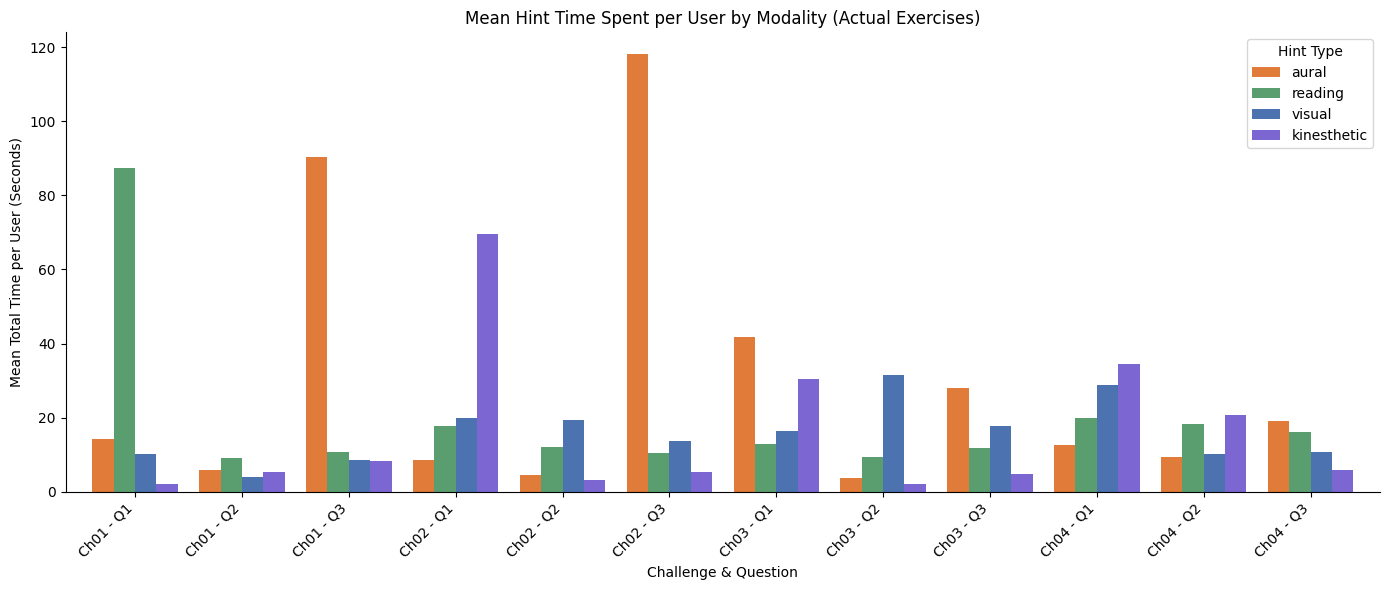

In [13]:
import matplotlib.pyplot as plt

# Filter mean_q_user for only the actual questions (q1, q2, q3)
actual_q_means = mean_q_user.reset_index()
actual_q_means = actual_q_means[actual_q_means['current_exerciseId'].isin(['q1', 'q2', 'q3'])].copy()

# Create a cleaner label for the x-axis
actual_q_means['challenge_q'] = actual_q_means['challengeId'].str.replace('challenge-', 'Ch') + " - " + actual_q_means['current_exerciseId'].str.upper()
actual_q_means = actual_q_means.set_index('challenge_q')[['aural', 'reading', 'visual', 'kinesthetic']]

# Plotting
fig, ax = plt.subplots(figsize=(14, 6))

# Use the same color palette defined in your setup
colors = [type_colors.get(c, '#CCCCCC') for c in actual_q_means.columns]
actual_q_means.plot(kind='bar', ax=ax, width=0.8, color=colors)

ax.set_ylabel('Mean Total Time per User (Seconds)')
ax.set_xlabel('Challenge & Question')
ax.set_title('Mean Hint Time Spent per User by Modality (Actual Exercises)')
ax.spines[['top', 'right']].set_visible(False)

plt.xticks(rotation=45, ha='right')
plt.legend(title="Hint Type")
plt.tight_layout()
plt.show()
